### Configuração inicial

Importando bibliotecas necessárias

In [761]:
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px

import warnings

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

# Primeira Parte: Métricas Tradicionais
-- Acceptance, Latency, CPU, Cache, Banda, Tempo de Decisão

--Extra: Energia

## Função Para Coletar Dados

In [762]:
results_flows_directories = glob.glob(
    "../../results/results_flows*/*"
)  # Caso mude a estrutura dos diretórios, esse caminho deve ser alterado
results_flows_directories

['../../results\\results_flows\\greedyb_s_50_p_4_a_1.0_c_0']

In [763]:
for alg_dir in results_flows_directories:
    simulacoes_okays = 0
    simu_exec_name = alg_dir.split("/")[-1].split("_")
    alg_name = simu_exec_name[1].split("\\")[1]
    number_of_fails = simu_exec_name[-1]
    ava = simu_exec_name[-3]
    print(alg_name, number_of_fails, ava)

greedyb 0 1.0


Resiliencia Coleta

In [764]:
import copy

aggregated_simulation_data = pd.DataFrame()
algos = {}


def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_flows_directories:
        simu_exec_name = alg_dir.split("/")[-1].split("_")
        alg_name = simu_exec_name[1].split("\\")[1]
        number_of_fails = simu_exec_name[-1]
        ava = simu_exec_name[-3]

        if alg_name == "g" or alg_name == "greedyb":
            alg_name = "Greedy"
            alg_name = "Greedy"
        if alg_name == "ga":
            alg_name = "GA"
        if alg_name == "msf":
            alg_name = "MSF"
        if alg_name == "goku":
            alg_name = "OSCIM"
        if alg_name == "vegeta":
            alg_name = "Resilient-OSCIM"
        if alg_name == "musfico":
            alg_name = "MuSFiCO"
        if alg_name == "old":
            alg_name = "All Backup"
        files = os.listdir(alg_dir)
        # print(f"Simulação: {alg_name}, {reliability}")
        # print("Quantidade de csv: ", len(files))

        if alg_name not in log_simu:
            log_simu[alg_name] = {"files": len(files), "simulacoes_sucesso": 0, "Nulos": 0}
        else:
            log_simu[alg_name]["files"] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                # print(simulation_df)
                simulation_df["sfc_id"].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue
            simulation_is_success = "sfc_cache_p3_30" in simulation_df["sfc_id"].values
            # print(simulation_is_success)
            if simulation_is_success:
                # Seleciona as métricas
                simulation_df = simulation_df[metricas_coleta]

                # Define o nome do algoritmo e incrementa a contagem de simulações
                simulation_df["algorithm"] = alg_name
                simulation_df["number_of_fails"] = number_of_fails
                simulation_df["availability"] = ava
                simulation_df["simulation"] = log_simu[alg_name]["simulacoes_sucesso"]

                copy.deepcopy(simulation_df)
                last_sfc_df = simulation_df.drop_duplicates(subset=["sfc_id"], keep="last")
                acceptance = last_sfc_df[
                    [
                        "success",
                        "algorithm",
                        "number_of_fails",
                        "availability",
                        "simulation",
                        "time_seconds",
                    ]
                ]
                acceptance.dropna(inplace=True)
                # acceptance = acceptance[(acceptance['time_seconds'] >= 240) & (acceptance['time_seconds'] <= 340)]
                acceptance = (
                    acceptance.groupby(["algorithm", "availability", "number_of_fails"])
                    .mean()
                    .reset_index()
                )
                acceptance["success"] = acceptance["success"] * 100
                acc_m = acceptance["success"].mean()
                # print(acc_m)
                simulation_df["acc_real"] = acc_m

                data_nla.append(simulation_df)

                # Incrementa a contagem de simulações de sucesso e soma os valores nulos
                log_simu[alg_name]["simulacoes_sucesso"] += 1
                log_simu[alg_name]["Nulos"] += sum(simulation_df.isnull().sum())

    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [765]:
# metricas_coleta = ["time_seconds","success","latency","cpu_utilization","cache_utilization","bandwidth_utilization",
#             "decision_time_ms","sfc_id","running_sfcs",'cpu_saved','shared_vnfs','cpu_resilient','cache_resilient']

metricas_coleta = [
    "time_seconds",
    "success",
    "latency",
    "cpu_utilization",
    "cache_utilization",
    "bandwidth_utilization",
    "decision_time_ms",
    "sfc_id",
    "running_sfcs",
    "cpu_saved",
    "shared_vnfs",
]

concatenate_data = collect_data_from_alg_directory(results_flows_directories, metricas_coleta)


Resumo das Simulações:
Algoritmo: Greedy
  Quantidade de arquivos: 1
  Simulações de sucesso: 1
  Dados nulos: 15



In [766]:
concatenate_data["success"] = concatenate_data["success"].map({True: 1, False: 0})

## Carregamento dos dados

In [767]:
concatenate_data = collect_data_from_alg_directory(results_flows_directories, metricas_coleta)
concatenate_data["success"] = concatenate_data["success"].map({True: 1, False: 0})


Resumo das Simulações:
Algoritmo: Greedy
  Quantidade de arquivos: 1
  Simulações de sucesso: 1
  Dados nulos: 15



In [768]:
# concatenate_data['availability'] = concatenate_data['availability'].astype(float)

In [769]:
# concatenate_data = concatenate_data[(concatenate_data['time_seconds'] >= 200) & (concatenate_data['time_seconds'] <= 900)]

In [770]:
print("ALGORITMOS: ")
algoritmos = list(concatenate_data.algorithm.unique())
print(algoritmos)

ALGORITMOS: 
['Greedy']


### Resultados de Aceitação e Latência (Com falha)

In [771]:
import pandas as pd


def plot_custom_boxplot(
    dataframe,
    x_col,
    y_col,
    title="Boxplot",
    x_label=None,
    y_label=None,
    color_col=None,
    y_range=None,
    legend_orientation="h",
    legend_y=1.1,
    legend_x=0.5,
    width=800,
    height=600,
):
    # Configurar rótulos personalizados
    labels = {x_col: x_label if x_label else x_col, y_col: y_label if y_label else y_col}

    # Criar o boxplot
    fig = px.box(dataframe, x=x_col, y=y_col, title=title, labels=labels, color=color_col)

    # Atualizar layout do gráfico
    fig.update_layout(
        yaxis=dict(range=y_range),  # Configura o limite do eixo Y (se fornecido)
        legend=dict(orientation=legend_orientation, y=legend_y, x=legend_x, xanchor="center"),
        title_x=0.5,  # Centralizar título
        width=width,  # Largura do gráfico
        height=height,  # Altura do gráfico
    )

    return fig

In [772]:
concatenate_data

,time_seconds,success,latency,cpu_utilization,cache_utilization,bandwidth_utilization,decision_time_ms,sfc_id,running_sfcs,cpu_saved,shared_vnfs,algorithm,number_of_fails,availability,simulation,acc_real
0,0.0,1,9.98,0.0108,0.0275,0.0027,11.133,sfc_cache_p1_1,0,0,1,Greedy,0,1.0,0,92.5
1,0.0,1,16.81,0.0108,0.0275,0.0027,8.121,sfc_unique_p1_1,0,0,1,Greedy,0,1.0,0,92.5
2,0.0,1,11.84,0.0183,0.0275,0.0055,15.747,sfc_cache_p2_1,0,4,4,Greedy,0,1.0,0,92.5
3,0.0,1,20.53,0.0183,0.0275,0.0055,9.475,sfc_unique_p2_1,0,4,4,Greedy,0,1.0,0,92.5
4,0.1,1,11.59,0.0258,0.0275,0.0082,12.250,sfc_cache_p3_1,0,8,7,Greedy,0,1.0,0,92.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,951.3,1,12.93,0.1792,0.3025,0.0779,11.247,sfc_unique_p2_50,0,32,34,Greedy,0,1.0,0,92.5
512,951.3,1,8.82,0.1867,0.3025,0.0815,13.917,sfc_cache_p3_50,0,36,37,Greedy,0,1.0,0,92.5
513,951.3,1,13.29,0.1867,0.3025,0.0815,8.177,sfc_unique_p3_50,0,36,37,Greedy,0,1.0,0,92.5
514,951.5,0,9.96,0.1867,0.3025,0.0815,13.817,sfc_cache_p4_50,0,36,37,Greedy,0,1.0,0,92.5


In [773]:
concatenate_data["algorithm"] = concatenate_data["algorithm"].replace(
    {"GA": "GA", "MSF": "MSF", "MuSFiCO": "MuSFiCO", "OSCIM/Greedy": "Greedy"}
)

In [774]:
acceptance = concatenate_data[
    [
        "success",
        "algorithm",
        "number_of_fails",
        "availability",
        "simulation",
        "time_seconds",
        "acc_real",
    ]
]
acceptance.dropna(inplace=True)
# acceptance = acceptance[(acceptance['time_seconds'] >= 240) & (acceptance['time_seconds'] <= 340)]
acceptance = (
    acceptance.groupby(["algorithm", "availability", "number_of_fails"]).mean().reset_index()
)
acceptance["success"] = acceptance["success"] * 100

In [775]:
# acceptance['success'] = acceptance['success'] * 100
# acceptance_last_sfc['success'] = acceptance_last_sfc['success'] * 100

In [776]:
acceptance

,algorithm,availability,number_of_fails,success,simulation,time_seconds,acc_real
0,Greedy,1.0,0,94.186047,0.0,488.648643,92.5


In [777]:
selected_availabilities = ["1.0", "0.99", "0.97", "0.95"]  # Substitua pelos valores desejados
filtered_data = acceptance[acceptance["availability"].isin(selected_availabilities)]

In [778]:
filtered_data

,algorithm,availability,number_of_fails,success,simulation,time_seconds,acc_real
0,Greedy,1.0,0,94.186047,0.0,488.648643,92.5


## Função de Plot

In [779]:
import pandas as pd


def create_grouped_bar_mplot(
    data, y_metric=None, y_title="", title="", ylim=None, width=9, height=6, font_size=28
):
    """
    Cria um gráfico de barras agrupado com Matplotlib com cores específicas para cada algoritmo.

    Parâmetros:
    - data (pd.DataFrame): Dados de entrada com colunas 'availability', 'success' e 'algorithm'.
    - y_metric (str): Nome da métrica para o eixo Y.
    - y_title (str): Rótulo do eixo Y.
    - title (str): Título do gráfico.
    - ylim (list, optional): Lista com dois valores [y_min, y_max] para definir os limites do eixo Y.
    - width (float, optional): Largura do gráfico.
    - height (float, optional): Altura do gráfico.
    - font_size (int, optional): Tamanho da fonte para os rótulos e título.

    Retorna:
    - fig, ax: Objeto de figura e eixo do Matplotlib.
    """
    if y_metric is None:
        raise ValueError(
            "A métrica para o eixo Y deve ser especificada usando o parâmetro 'y_metric'."
        )

    # Criar figura e eixos
    fig, ax = plt.subplots(figsize=(width, height))

    # Obter valores únicos de 'availability' e 'algorithm'
    availability_values = data["availability"].unique()
    algorithms = data["algorithm"].unique()

    # Definir posições para as barras
    x = np.arange(len(availability_values))
    bar_width = 0.8 / len(algorithms)  # Largura das barras (dividida pelo número de algoritmos)

    # Definir cores específicas para cada algoritmo
    algorithm_colors = {"GA": "#FE4A49", "Greedy": "#2AB7CA", "MSF": "#FED766"}

    # Criar as barras para cada algoritmo
    for i, algorithm in enumerate(algorithms):
        algorithm_data = data[data["algorithm"] == algorithm]
        ax.bar(
            x + i * bar_width,  # Ajustar posição das barras
            algorithm_data[y_metric],
            width=bar_width,
            label=algorithm,
            edgecolor="black",  # Borda preta
            linewidth=1.6,  # Largura da borda
            color=algorithm_colors.get(algorithm, "#888888"),  # Cor definida ou cinza padrão
        )

    # Adicionar grade horizontal
    ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="gray", alpha=0.7)

    # Configurar os ticks e rótulos do eixo X
    ax.set_xticks(x + bar_width * (len(algorithms) - 1) / 2)
    ax.set_xticklabels(availability_values, fontsize=font_size - 4)

    # Configurar rótulos dos eixos e título
    ax.set_xlabel("Availability", fontsize=font_size)
    ax.set_ylabel(y_title, fontsize=font_size)
    ax.set_title(title, fontsize=font_size + 4, pad=30)

    # Configurar limites do eixo Y
    if ylim:
        ax.set_ylim(ylim)

    ax.tick_params(axis="y", labelsize=font_size - 4)

    # Configurar a legenda
    ax.legend(
        fontsize=font_size - 15,
        title_fontsize=font_size - 6,
        loc="upper center",
        bbox_to_anchor=(0.48, 1.15),
        ncol=len(algorithms),
    )

    # Ajustar layout
    plt.tight_layout()

    if y_metric:
        plt.savefig(f"{y_metric}.pdf", format="pdf", bbox_inches="tight")

    return fig, ax

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='Acceptance Ratio (%)'>)

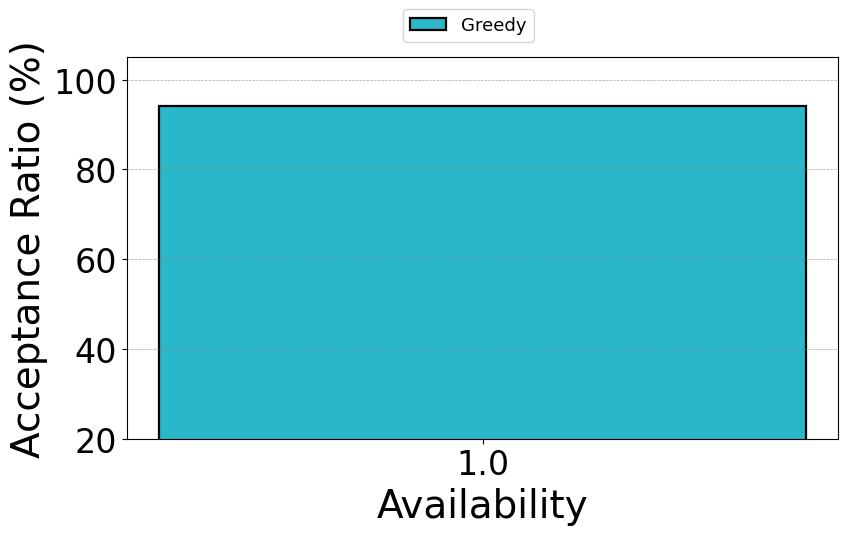

In [780]:
create_grouped_bar_mplot(
    filtered_data, y_metric="success", y_title="Acceptance Ratio (%)", title="", ylim=[20, 105]
)

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='Acceptance Ratio (%)'>)

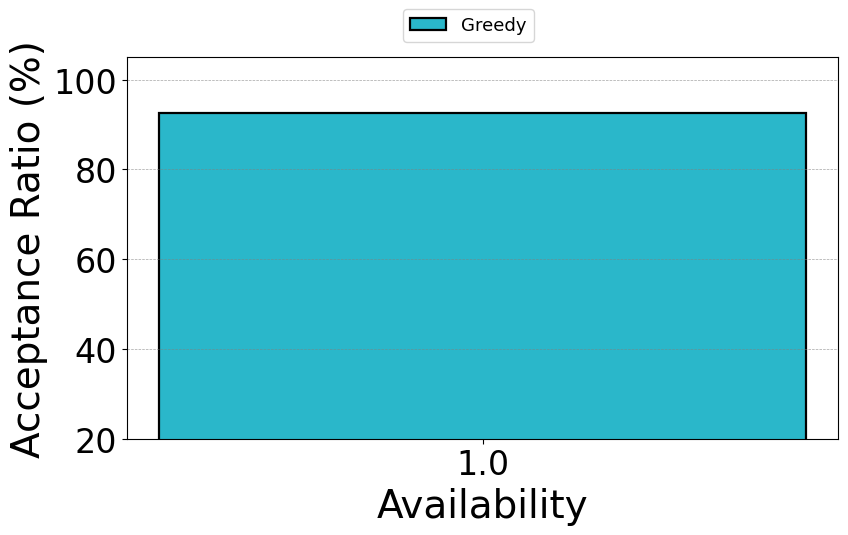

In [781]:
create_grouped_bar_mplot(
    filtered_data, y_metric="acc_real", y_title="Acceptance Ratio (%)", title="", ylim=[20, 105]
)

In [782]:
latency = concatenate_data[
    ["latency", "algorithm", "number_of_fails", "availability", "simulation", "time_seconds"]
]
latency.dropna(inplace=True)
# latency = latency[(latency['time_seconds'] >= 240) & (latency['time_seconds'] <= 340)]
latency = latency.groupby(["algorithm", "availability", "number_of_fails"]).mean().reset_index()

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='Latency (ms)'>)

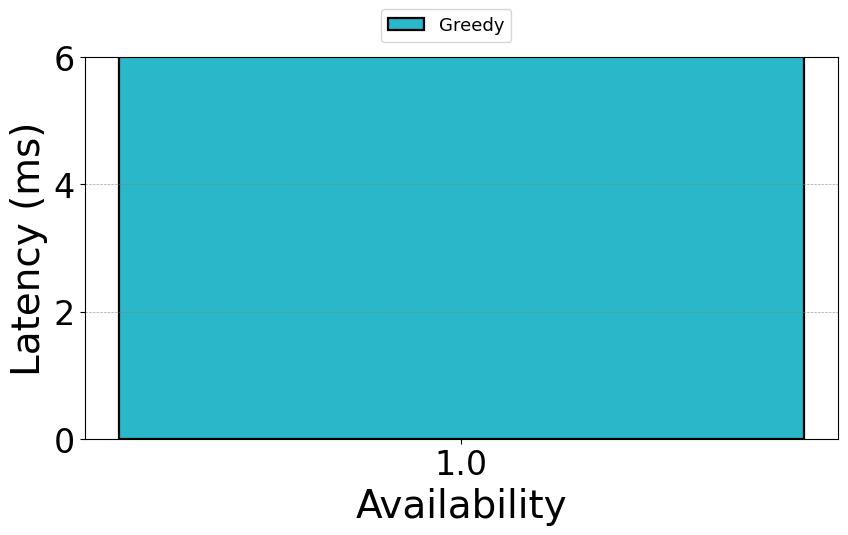

In [783]:
create_grouped_bar_mplot(
    latency, y_metric="latency", y_title="Latency (ms)", title="", ylim=[0, 6]
)

### Métricas de Consumo

In [784]:
# consume_metrics = concatenate_data[['cpu_utilization', 'bandwidth_utilization','cache_utilization','cpu_saved','number_of_fails','availability',
#                                          'shared_vnfs','simulation','decision_time_ms','algorithm','time_seconds','cpu_resilient','cache_resilient']]

consume_metrics = concatenate_data[
    [
        "cpu_utilization",
        "bandwidth_utilization",
        "cache_utilization",
        "cpu_saved",
        "number_of_fails",
        "availability",
        "shared_vnfs",
        "simulation",
        "decision_time_ms",
        "algorithm",
        "time_seconds",
    ]
]

In [785]:
# Tempo de Análise, descomente isso se você quiser definir isso
# filtered_data = consume_metrics[(consume_metrics['time_seconds'] >= 240) & (consume_metrics['time_seconds'] <= 400)]

In [786]:
df_consume_metrics = (
    consume_metrics.groupby(["availability", "algorithm", "number_of_fails"]).mean().reset_index()
)
df_consume_metrics["cpu_utilization"] = df_consume_metrics["cpu_utilization"] * 100
df_consume_metrics["bandwidth_utilization"] = df_consume_metrics["bandwidth_utilization"] * 100
df_consume_metrics["cache_utilization"] = df_consume_metrics["cache_utilization"] * 100
# df_consume_metrics['cpu_resilient'] = df_consume_metrics['cpu_resilient'] * 100
# df_consume_metrics['cache_resilient'] = df_consume_metrics['cache_resilient'] * 100

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='CPU Utilization (%)'>)

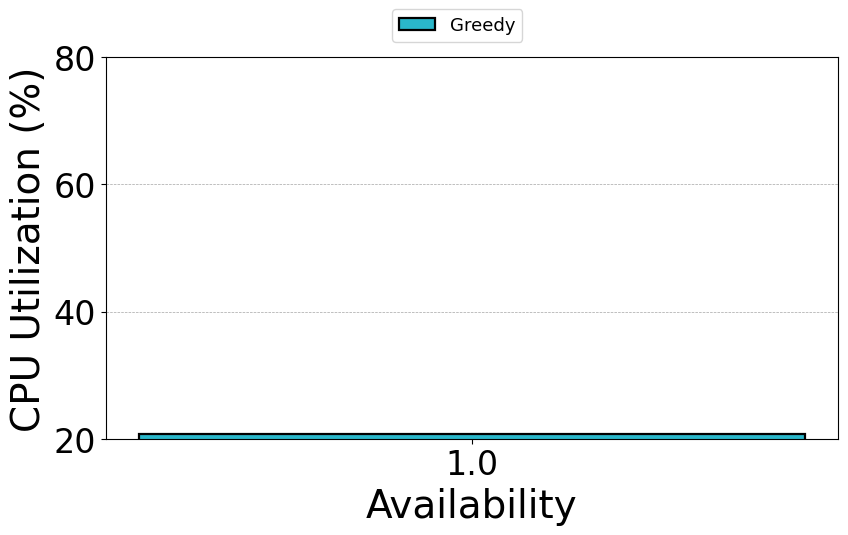

In [787]:
create_grouped_bar_mplot(
    df_consume_metrics, y_metric="cpu_utilization", y_title="CPU Utilization (%)", ylim=[20, 80]
)

In [788]:
# create_grouped_bar_mplot(df_consume_metrics,y_metric='cpu_resilient',y_title='CPU Resilient (%)', ylim=[20, 80])

In [789]:
# create_grouped_bar_mplot(df_consume_metrics,y_metric='cache_resilient',y_title='Cache Resilient (%)', ylim=[0, 50])

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='Cache Utilization (%)'>)

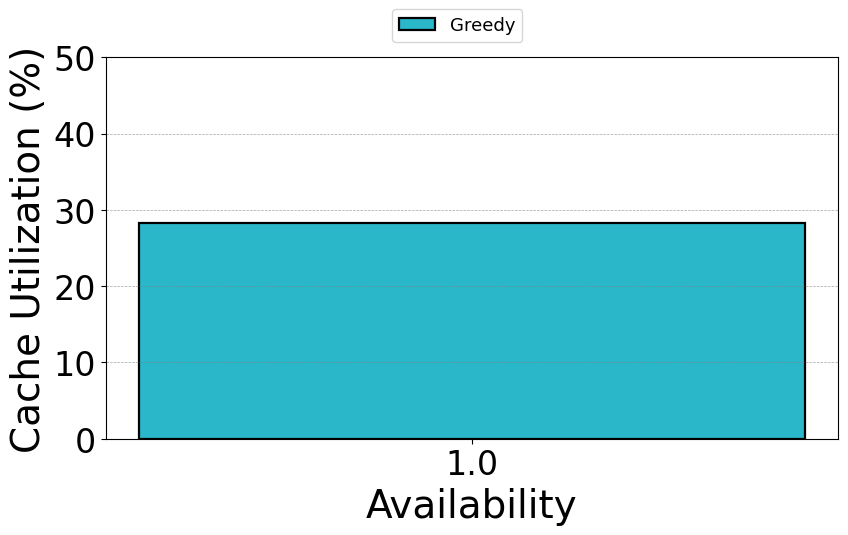

In [790]:
create_grouped_bar_mplot(
    df_consume_metrics,
    y_metric="cache_utilization",
    y_title="Cache Utilization (%)",
    title="",
    ylim=[0, 50],
)

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='Bandwidth Utilization (%)'>)

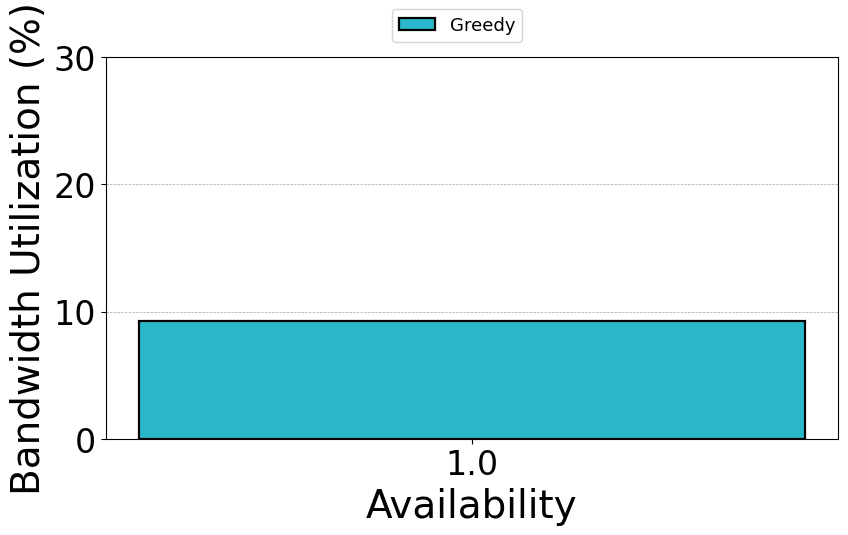

In [791]:
create_grouped_bar_mplot(
    df_consume_metrics,
    y_metric="bandwidth_utilization",
    y_title="Bandwidth Utilization (%)",
    title="",
    ylim=[0, 30],
)

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='Decision Time (ms)'>)

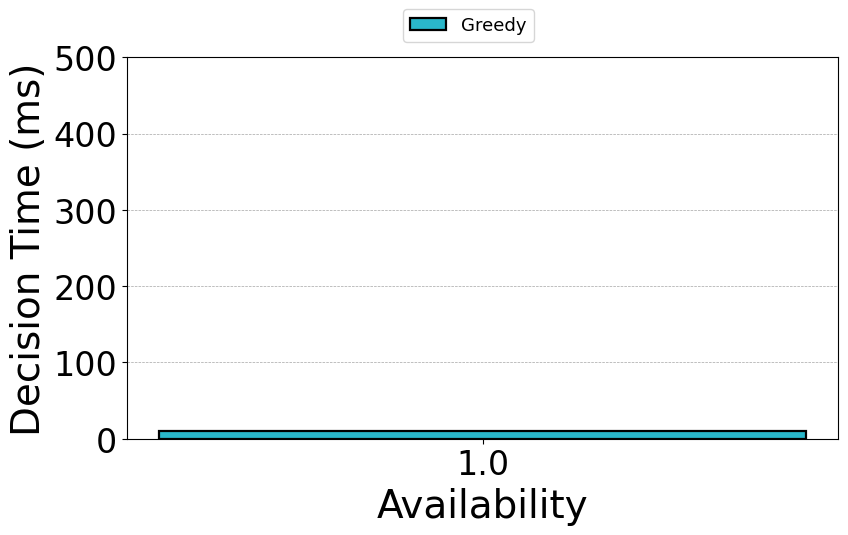

In [792]:
create_grouped_bar_mplot(
    df_consume_metrics,
    y_metric="decision_time_ms",
    y_title="Decision Time (ms)",
    title="",
    ylim=[0, 500],
)

### EXTRA: Energia

In [793]:
energy = df_consume_metrics[["cpu_utilization", "algorithm", "availability", "number_of_fails"]]
# energy = energy.groupby(['algorithm','simulation']).mean().reset_index()

In [794]:
# energy = energy.groupby(['algorithm','simulation']).mean().reset_index()

# Parâmetros do processador
power = 100  # em watts
ips = 96_100 * 1e6
# Cálculo do EPI (em joules por instrução)
epi = power / ips
# Adicionando a coluna de EPI ajustada pela utilização
# energy["EPI"] = epi #* energy["cpu_utilization"]
energy["energy_consumption_KJ"] = (
    epi * (energy["cpu_utilization"] * ips) * 100 / 1000
)  # Periodo de 100 segundos

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='Availability', ylabel='Energy Consumption (KJ)'>)

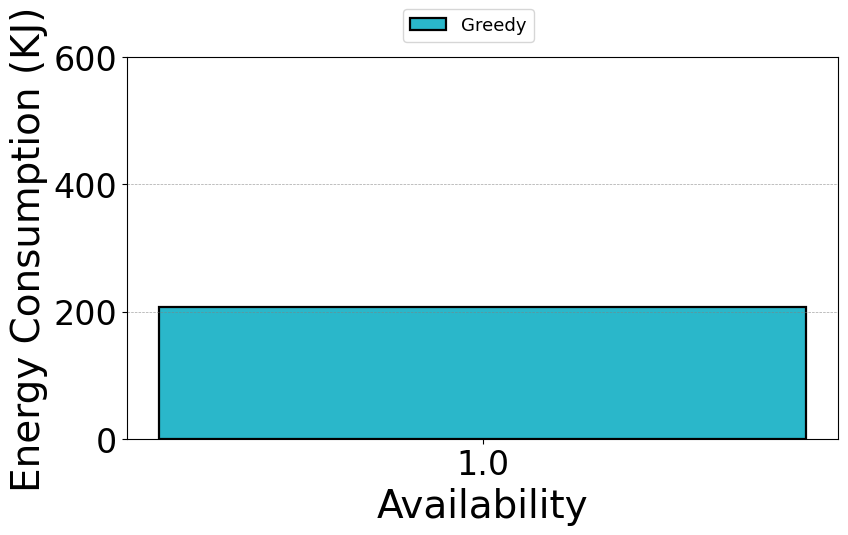

In [795]:
create_grouped_bar_mplot(
    energy,
    y_metric="energy_consumption_KJ",
    y_title="Energy Consumption (KJ)",
    title="",
    ylim=[0, 600],
)

# Segunda Parte:  Métricas de Resiliência

-- Taxa de Recover, diferença de latência e tempo de recuperação

In [796]:
results_res_directories = glob.glob(
    "../../results/results_resilient*/*"
)  # Caso mude a estrutura dos diretórios, esse caminho deve ser alterado
results_res_directories

['../../results\\results_resilient\\greedyb_s_50_p_4_a_1.0_c_0']

In [797]:
aggregated_simulation_data = pd.DataFrame()
algos = {}


def res_collect_data_from_alg_directory(results_res_directories):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_res_directories:
        simu_exec_name = alg_dir.split("/")[-1].split("_")
        alg_name = simu_exec_name[1].split("\\")[1]
        simu_exec_name[-1]
        simu_exec_name[-3]

        # alg_name = simu_exec_name[1].split("\\")[1]# simu_exec_name[3].split(f'\\')[1]
        # reliability = simu_exec_name[-1]
        if alg_name == "g" or alg_name == "greedyb":
            alg_name = "Greedy"
        if alg_name == "ga":
            alg_name = "GA"
        if alg_name == "msf":
            alg_name = "MSF"
        if alg_name == "goku":
            alg_name = "OSCIM"
        if alg_name == "vegeta":
            alg_name = "Resilient-OSCIM"
        if alg_name == "musfico":
            alg_name = "MuSFiCO"
        if alg_name == "old":
            alg_name = "All Backup"
        files = os.listdir(alg_dir)
        # print(f"Simulação: {alg_name}, {reliability}")
        # print("Quantidade de csv: ", len(files))

        if alg_name not in log_simu:
            log_simu[alg_name] = {"files": len(files), "simulacoes_sucesso": 0, "Nulos": 0}
        else:
            log_simu[alg_name]["files"] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue

            if not simulation_df.empty:
                # Calculations
                mean_data_frame = pd.DataFrame()
                recover_success_rate = simulation_df["recover_success"].mean()
                backup_success_rate = simulation_df["backup_success"].mean()
                latency_diff_mean = simulation_df["latency_diff"].dropna().mean()
                latency_degrad_mean = simulation_df["latency_deg"].dropna().mean()

                time_to_recover_mean = simulation_df["time_to_recover"].dropna().mean()
                backup_efficient = simulation_df["backup_efficient"].dropna().max()

                # Cálculo do percentual de melhoria da latência
                improvement_percentage = ((5 - latency_diff_mean) / 10) * 100

                mean_data_frame["recover_success"] = [recover_success_rate]
                mean_data_frame["backup_success"] = [backup_success_rate]
                mean_data_frame["backup_efficient"] = [backup_efficient]
                mean_data_frame["latency_diff"] = [latency_diff_mean]
                mean_data_frame["latency_deg"] = [latency_degrad_mean]
                mean_data_frame["latency_improvement"] = [improvement_percentage]
                mean_data_frame["time_to_recover"] = [time_to_recover_mean]

                # Seleciona as métricas relevantes
                mean_data_frame["algorithm"] = alg_name
                mean_data_frame["simulation"] = log_simu[alg_name]["simulacoes_sucesso"]
                # print(mean_data_frame)
                data_nla.append(mean_data_frame)

                # Incrementa a contagem de simulações de sucesso e soma os valores nulos
                log_simu[alg_name]["simulacoes_sucesso"] += 1
                log_simu[alg_name]["Nulos"] += sum(mean_data_frame.isnull().sum())
    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [798]:
res_aggregated_simulation_data = res_collect_data_from_alg_directory(results_res_directories)


Resumo das Simulações:
Algoritmo: Greedy
  Quantidade de arquivos: 1
  Simulações de sucesso: 0
  Dados nulos: 0



In [799]:
# res_aggregated_simulation_data = res_aggregated_simulation_data.sort_values(by="algorithm")
# res_aggregated_simulation_data


In [800]:
# def plot_seaborn_boxplot(data, x_col, y_col, title, x_title, y_title, hatches):
#     """
#     Cria um boxplot utilizando Seaborn, aplicando cores e hachuras específicas para cada algoritmo.

#     Parâmetros:
#     - data (pd.DataFrame): Dados de entrada.
#     - x_col (str): Nome da coluna para o eixo X (categorias).
#     - y_col (str): Nome da coluna para o eixo Y (valores numéricos).
#     - title (str): Título do gráfico.
#     - x_title (str): Rótulo do eixo X.
#     - y_title (str): Rótulo do eixo Y.
#     - hatches (list): Lista de padrões de hachura para diferenciar os algoritmos.

#     Retorna:
#     - Exibe o gráfico gerado.
#     """
#     # Definir cores específicas para cada algoritmo
#     algorithm_colors = {
#         'GA': '#FE4A49',
#         'Greedy': '#2AB7CA',
#         'MSF': '#FED766'
#     }

#     # Remover valores NaN
#     data = data.dropna(subset=[x_col, y_col])

#     # Criar a figura e os eixos
#     fig, ax = plt.subplots(figsize=(8, 6))
#     plt.rcParams.update({'font.size': 40})

#     # Criar o boxplot com as cores definidas
#     boxplot = sns.boxplot(data=data, x=x_col, y=y_col, ax=ax, palette=algorithm_colors, showfliers=False)

#     # Aplicar hachuras aos retângulos do boxplot
#     for patch, hatch in zip(boxplot.patches, hatches):
#         patch.set_hatch(hatch)
#         patch.set_edgecolor('black')

#     # Configurar título e rótulos
#     ax.set_title(title, fontsize=24)
#     ax.set_xlabel(x_title, fontsize=22)
#     ax.set_ylabel(y_title, fontsize=22)
#     ax.grid(True, axis='y', linestyle='--', alpha=0.7)
#     ax.tick_params(axis='y', labelsize=19)
#     ax.tick_params(axis='x', labelsize=19)

#     # Salvar o gráfico em PDF
#     plt.savefig(f"{y_col}_res.pdf", format="pdf")
#     plt.show()

#     # Remover valores NaN
#     data = data.dropna(subset=[x_col, y_col])

#     # Criar a figura e os eixos
#     fig, ax = plt.subplots(figsize=(8, 6))
#     plt.rcParams.update({'font.size': 40})

#     # Criar o boxplot com as cores definidas
#     sns.boxplot(data=data, x=x_col, y=y_col, ax=ax, palette=algorithm_colors, showfliers=False)

#     # Configurar título e rótulos
#     ax.set_title(title, fontsize=24)
#     ax.set_xlabel(x_title, fontsize=22)
#     ax.set_ylabel(y_title, fontsize=22)
#     ax.grid(True, axis='y', linestyle='--', alpha=0.7)
#     ax.tick_params(axis='y', labelsize=19)
#     ax.tick_params(axis='x', labelsize=19)

#     # Salvar o gráfico em PDF
#     plt.savefig(f"{y_col}_res.pdf", format="pdf")
#     plt.show()


# data = res_aggregated_simulation_data

# hatches = ['//', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']  # Padrões de hachura
# # light_gray_palette = sns.color_palette("light:#949494", n_colors=len(res_aggregated_simulation_data['algorithm'].unique()))

# plot_seaborn_boxplot(
#     data=data,
#     x_col='algorithm',
#     y_col='recover_success',
#     title='Recover Success in Failure Scenario',
#     x_title='Algorithms',
#     y_title='Recover Success',
#     hatches=hatches
# )

# plot_seaborn_boxplot(
#     data=data,
#     x_col='algorithm',
#     y_col='time_to_recover',
#     title='Time to Recover in Failure Scenario',
#     x_title='Algorithms',
#     y_title='Time to Recover (s)',
#     hatches=hatches
# )

# plot_seaborn_boxplot(
#     data=data,
#     x_col='algorithm',
#     y_col='backup_success',
#     title='Backup Success',
#     x_title='Algorithms',
#     y_title='Backup Success',
#     hatches=hatches
# )

# plot_seaborn_boxplot(
#     data=data,
#     x_col='algorithm',
#     y_col='backup_efficient',
#     title='Backup Efficiency',
#     x_title='Algorithms',
#     y_title='Backup Efficiency',
#     hatches=hatches
# )

# plot_seaborn_boxplot(
#     data=data,
#     x_col='algorithm',
#     y_col='latency_deg',
#     title='Latency degradation',
#     x_title='Algorithms',
#     y_title='Latency degradation',
#     hatches=hatches
# )


In [801]:
# import matplotlib as mpl
# import seaborn as sns

# def plot_box(x_col, y_col, data, palette, hatches, x_title, y_title):
#     ax = sns.boxplot(x=x_col, y=y_col, data=data,palette=palette, linewidth=1.6)

#     ax.set_xlabel(x_title, fontsize=22)
#     ax.set_ylabel(y_title, fontsize=22)
#     ax.grid(True, axis='y', linestyle='--', alpha=0.7)
#     ax.tick_params(axis='y', labelsize=19)
#     ax.tick_params(axis='x', labelsize=19)

#     # select the correct patches
#     patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
#     # the number of patches should be evenly divisible by the number of hatches
#     h = hatches * (len(patches) // len(hatches))
#     # iterate through the patches for each subplot
#     for patch, hatch in zip(patches, h):
#         patch.set_hatch(hatch)
#         #fc = patch.get_facecolor()
#         patch.set_edgecolor('0.5')
#         #patch.set_facecolor('none')

#     plt.tight_layout

#     fig = ax.get_figure()

#     fig.savefig(f"{y_col}_res_2.pdf", format="pdf",bbox_inches='tight')

# hatches = ['/', '\\', '+', 'x']
# light_gray_palette = sns.color_palette("light:#949494", n_colors=len(res_aggregated_simulation_data['algorithm'].unique()))

# plot_box(x_col='algorithm',
#          y_col='recover_success',
#          data = res_aggregated_simulation_data,
#          palette=light_gray_palette,
#          hatches=hatches,
#          x_title='Algorithms',
#          y_title='Recover Success')


In [802]:
# def plot_box2(x_col, y_col, data, palette, hatches, x_title, y_title):

#     data = data.dropna(subset=[x_col, y_col])
#     ax = sns.boxplot(x=x_col, y=y_col, data=data,palette=palette,linewidth=1.6)

#     ax.set_xlabel(x_title, fontsize=22)
#     ax.set_ylabel(y_title, fontsize=22)
#     ax.grid(True, axis='y', linestyle='--', alpha=0.7)
#     ax.tick_params(axis='y', labelsize=19)
#     ax.tick_params(axis='x', labelsize=19)


#     patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
#     h = hatches * (len(patches) // len(hatches))
#     for patch, hatch in zip(patches, h):
#         patch.set_hatch(hatch)
#         patch.set_edgecolor('0.5')

#     fig = ax.get_figure()

#     fig.savefig(f"{y_col}_res_2.pdf", format="pdf",bbox_inches='tight')

# plot_box2(x_col='algorithm',
#           y_col='time_to_recover',
#           data = res_aggregated_simulation_data,
#           palette=light_gray_palette,
#           hatches=hatches,
#           x_title='Algorithms',
#           y_title='Time to Recover (s)'
#           )

# Terceira Parte: Gráficos Comparativos

Gráficos De Comparação

### Carregamento dos Dados

In [803]:
aggregated_simulation_data = pd.DataFrame()
algos = {}
# def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
#     data_nla = []
#     log_simu = {}  # Essa variável serve apenas para verificar as simulações

#     for alg_dir in results_flows_directories:
#         simulacoes_okays = 0
#         simu_exec_name = alg_dir.split('/')[-1].split('_')
#         alg_name = simu_exec_name[1].split("\\")[1]
#         number_of_fails = simu_exec_name[-1]
#         ava = simu_exec_name[-3]
#         if alg_name == 'g' or alg_name == 'greedyb':
#             alg_name = 'Greedy'
#             alg_name = 'Greedy'
#         if alg_name == 'ga':
#             alg_name =  'GA'
#         if alg_name == 'msf':
#             alg_name = 'MSF'
#         if alg_name == 'goku':
#             alg_name = 'OSCIM'
#         if alg_name == 'vegeta':
#             alg_name = 'Resilient-OSCIM'
#         if alg_name == 'musfico':
#             alg_name = 'MuSFiCO'
#         if alg_name == 'old':
#             alg_name = 'All Backup'
#         files = os.listdir(alg_dir)
#         #print(f"Simulação: {alg_name}, {reliability}")
#         #print("Quantidade de csv: ", len(files))

#         if alg_name not in log_simu:
#             log_simu[alg_name] = {'files': len(files), 'simulacoes_sucesso': 0, 'Nulos': 0}
#         else:

#             log_simu[alg_name]['files'] += len(files)

#         for file in files:
#             data_path = os.path.join(alg_dir, file)
#             try:
#                 simulation_df = pd.read_csv(data_path)
#                 #print(simulation_df)
#                 sfc_id_values = simulation_df['sfc_id'].values
#             except Exception as e:
#                 print(f"Erro ao ler o arquivo {file}: {e}")
#                 continue
#             simulation_is_success = 'sfc_cache_p3_48' in simulation_df['sfc_id'].values
#             #print(simulation_is_success)
#             if simulation_is_success:
#                 # Seleciona as métricas
#                 simulation_df = simulation_df[metricas_coleta]

#                 # Define o nome do algoritmo e incrementa a contagem de simulações
#                 simulation_df['algorithm'] = alg_name
#                 simulation_df['number_of_fails'] = number_of_fails
#                 simulation_df['availability'] = ava
#                 simulation_df['simulation'] = log_simu[alg_name]['simulacoes_sucesso']

#                 data_nla.append(simulation_df)

#                 # Incrementa a contagem de simulações de sucesso e soma os valores nulos
#                 log_simu[alg_name]['simulacoes_sucesso'] += 1
#                 log_simu[alg_name]['Nulos'] += sum(simulation_df.isnull().sum())

#     if data_nla:
#         data_nla_f = pd.concat(data_nla)
#     else:
#         data_nla_f = pd.DataFrame()

#     print("\nResumo das Simulações:")
#     for alg, info in log_simu.items():
#         print(f"Algoritmo: {alg}")
#         print(f"  Quantidade de arquivos: {info['files']}")
#         print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
#         print(f"  Dados nulos: {info['Nulos']}")
#         print()

#     return data_nla_f

metricas_coleta = [
    "time_seconds",
    "success",
    "latency",
    "cpu_utilization",
    "cache_utilization",
    "bandwidth_utilization",
    "decision_time_ms",
    "sfc_id",
    "running_sfcs",
    "cpu_saved",
    "shared_vnfs",
]

concatenate_data = collect_data_from_alg_directory(results_flows_directories, metricas_coleta)

concatenate_data["success"] = concatenate_data["success"].map({True: 1, False: 0})
concatenate_data["success"] = concatenate_data["success"] * 100
concatenate_data["cpu_utilization"] = concatenate_data["cpu_utilization"] * 100
concatenate_data["cache_utilization"] = concatenate_data["cache_utilization"] * 100
concatenate_data["bandwidth_utilization"] = concatenate_data["bandwidth_utilization"] * 100


Resumo das Simulações:
Algoritmo: Greedy
  Quantidade de arquivos: 1
  Simulações de sucesso: 1
  Dados nulos: 15



### Separação dos Dados

In [804]:
# Seleção do período de análise
# concatenate_data = concatenate_data[(concatenate_data['time_seconds'] >= 200) & (concatenate_data['time_seconds'] <= 900)]

In [805]:
# Separação dos dados com falha e sem falha
dados_com_falha = concatenate_data[(concatenate_data["availability"] != "1.0")]
dados_sem_falha = concatenate_data[(concatenate_data["availability"] == "1.0")]

In [806]:
def process_data(data, columns):
    processed = data[columns]
    processed.dropna(inplace=True)
    return processed.groupby(["algorithm", "simulation"]).mean().reset_index()


# Tratamento da Aceitação
acceptance_columns = ["success", "algorithm", "simulation", "time_seconds"]
acceptance_sem_falha = process_data(dados_sem_falha, acceptance_columns)
acceptance_com_falha = process_data(dados_com_falha, acceptance_columns)

# Tratamento da Latência
latency_columns = ["latency", "algorithm", "simulation", "time_seconds"]
latency_sem_falha = process_data(dados_sem_falha, latency_columns)
latency_com_falha = process_data(dados_com_falha, latency_columns)

In [807]:
dados_sem_falha = dados_sem_falha.drop(
    ["time_seconds", "sfc_id", "availability", "number_of_fails"], axis=1
)
dados_com_falha = dados_com_falha.drop(
    ["time_seconds", "sfc_id", "availability", "number_of_fails"], axis=1
)

dados_sem_falha = dados_sem_falha.groupby(["algorithm", "simulation"]).mean().reset_index()
dados_com_falha = dados_com_falha.groupby(["algorithm", "simulation"]).mean().reset_index()

In [808]:
dados_consumo_sem_falha = dados_sem_falha[
    [
        "cpu_utilization",
        "bandwidth_utilization",
        "cache_utilization",
        "cpu_saved",
        "shared_vnfs",
        "simulation",
        "decision_time_ms",
        "algorithm",
    ]
]

dados_consumo_com_falha = dados_com_falha[
    [
        "cpu_utilization",
        "bandwidth_utilization",
        "cache_utilization",
        "cpu_saved",
        "shared_vnfs",
        "simulation",
        "decision_time_ms",
        "algorithm",
    ]
]

In [809]:
# Inserção dos Dados de Energia
# Parâmetros do processador
power = 100  # em watts
ips = 96_100 * 1e6
# Cálculo do EPI (em joules por instrução)
epi = power / ips
# Adicionando a coluna de EPI ajustada pela utilização
# energy["EPI"] = epi #* energy["cpu_utilization"]

dados_consumo_sem_falha["energy_consumption_KJ"] = (
    epi * (dados_consumo_sem_falha["cpu_utilization"] * ips) * 100 / 1000
)  # Periodo de 100 segundos
dados_consumo_com_falha["energy_consumption_KJ"] = (
    epi * (dados_consumo_com_falha["cpu_utilization"] * ips) * 100 / 1000
)  # Periodo de 100 segundos

### Função de Plot lado a lado

In [810]:
# import pandas as pd
# import plotly.subplots as sp
# import plotly.graph_objects as go

# def plot_dual_boxplot(dataframe1, dataframe2, x_col, y_col,
#                       title1="Boxplot 1", title2="Boxplot 2",
#                       x_label=None, y_label=None, color_col1=None, color_col2=None,
#                       y_range=None, width=1200, height=600):
#     # Configurar rótulos personalizados
#     labels = {x_col: x_label if x_label else x_col, y_col: y_label if y_label else y_col}

#     # Criar o primeiro boxplot
#     fig1 = px.box(dataframe1, x=x_col, y=y_col, color=color_col1, labels=labels, title=title1)

#     # Criar o segundo boxplot
#     fig2 = px.box(dataframe2, x=x_col, y=y_col, color=color_col2, labels=labels, title=title2)

#     # Criar subplots lado a lado
#     fig = sp.make_subplots(rows=1, cols=2, subplot_titles=[title1, title2])

#     # Adicionar trace do primeiro boxplot
#     for trace in fig1.data:
#         fig.add_trace(trace, row=1, col=1)

#     # Adicionar trace do segundo boxplot
#     for trace in fig2.data:
#         fig.add_trace(trace, row=1, col=2)

#     # Atualizar layout
#     fig.update_layout(
#         yaxis=dict(range=y_range),
#         yaxis2=dict(range=y_range),  # Configura o limite do eixo Y para o segundo gráfico
#         title_x=0.5,
#         width=width,
#         height=height
#     )

#     return fig

In [811]:
import pandas as pd

hatches = ["/", "\\", "|", "-", "+", "x", "o", "O", ".", "*"]  # Padrões de hachura


def mplot_dual_boxplot_deprecated(
    dataframe1,
    dataframe2,
    x_col,
    y_col,
    title1="Boxplot 1",
    title2="Boxplot 2",
    x_label=None,
    y_label=None,
    color_col1=None,
    color_col2=None,
    y_range=None,
    width=14,
    height=6,
    y_title="",
    x_title="",
):
    """
    Plota dois boxplots lado a lado utilizando Seaborn com Matplotlib.

    Parameters:
        dataframe1 (pd.DataFrame): Primeiro DataFrame.
        dataframe2 (pd.DataFrame): Segundo DataFrame.
        x_col (str): Coluna do eixo X.
        y_col (str): Coluna do eixo Y.
        title1 (str): Título do primeiro gráfico.
        title2 (str): Título do segundo gráfico.
        x_label (str): Rótulo do eixo X.
        y_label (str): Rótulo do eixo Y.
        color_col1 (str): Coluna para cores no primeiro gráfico (não suportado no Seaborn).
        color_col2 (str): Coluna para cores no segundo gráfico (não suportado no Seaborn).
        y_range (tuple): Limites do eixo Y.
        width (float): Largura da figura.
        height (float): Altura da figura.
    """
    # Criar figura e eixos
    fig, axes = plt.subplots(1, 2, figsize=(width, height))

    # Configurar tamanho da fonte
    plt.rcParams.update({"font.size": 24})

    # Paleta de cinza clara
    light_gray_palette = sns.color_palette(
        "light:#949494", n_colors=len(dataframe1[x_col].unique())
    )

    # Primeiro boxplot com hachuras
    ax1 = sns.boxplot(data=dataframe1, x=x_col, y=y_col, ax=axes[0], palette=light_gray_palette)
    patches = [patch for patch in ax1.patches if type(patch) == mpl.patches.PathPatch]
    h = hatches * (len(patches) // len(hatches))
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        patch.set_edgecolor("0.5")
    axes[0].set_title(title1)
    axes[0].set_xlabel(x_title, fontsize=24)
    axes[0].set_ylabel(y_title, fontsize=24)
    axes[0].grid(True, axis="y", linestyle="--", alpha=0.7)  # Adicionar grid horizontal

    # Segundo boxplot com hachuras
    ax2 = sns.boxplot(data=dataframe2, x=x_col, y=y_col, ax=axes[1], palette=light_gray_palette)
    patches = [patch for patch in ax2.patches if type(patch) == mpl.patches.PathPatch]
    h = hatches * (len(patches) // len(hatches))
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        patch.set_edgecolor("0.5")
    axes[1].set_title(title2)
    axes[1].set_xlabel(x_title, fontsize=24)
    axes[1].set_ylabel(None)
    axes[1].grid(True, axis="y", linestyle="--", alpha=0.7)  # Adicionar grid horizontal

    axes[0].tick_params(axis="y", labelsize=21)
    axes[1].tick_params(axis="y", labelsize=21)
    axes[0].tick_params(axis="x", labelsize=21)
    axes[1].tick_params(axis="x", labelsize=21)
    # Ajustar os limites do eixo Y, se fornecido
    if y_range:
        axes[0].set_ylim(y_range)
        axes[1].set_ylim(y_range)

    # Ajustar layout
    plt.tight_layout()

    if y_col:
        plt.savefig(f"{y_col}_comp.pdf", format="pdf", pad_inches=0)

    plt.show()

In [812]:
import pandas as pd
import matplotlib as mpl  # Importação necessária para hachuras

hatches = ["/", "\\", "+", "x", "+", "x", "o", "O", ".", "*"]  # Padrões de hachura


def mplot_dual_boxplot(
    dataframe1,
    dataframe2,
    x_col,
    y_col,
    title1="Boxplot 1",
    title2="Boxplot 2",
    x_title=None,
    y_title=None,
    y_range=None,
    width=14,
    height=6,
):
    """
    Plota dois boxplots lado a lado utilizando Seaborn com Matplotlib, aplicando cores e hachuras específicas para cada algoritmo.

    Parameters:
        dataframe1 (pd.DataFrame): Primeiro DataFrame.
        dataframe2 (pd.DataFrame): Segundo DataFrame.
        x_col (str): Coluna do eixo X.
        y_col (str): Coluna do eixo Y.
        title1 (str): Título do primeiro gráfico.
        title2 (str): Título do segundo gráfico.
        x_title (str): Rótulo do eixo X.
        y_title (str): Rótulo do eixo Y.
        y_range (tuple): Limites do eixo Y.
        width (float): Largura da figura.
        height (float): Altura da figura.
    """
    # Definir cores específicas para cada algoritmo
    algorithm_colors = {"GA": "#FE4A49", "Greedy": "#2AB7CA", "MSF": "#FED766"}

    # Criar figura e eixos
    fig, axes = plt.subplots(1, 2, figsize=(width, height))

    # Configurar tamanho da fonte
    plt.rcParams.update({"font.size": 24})

    # Primeiro boxplot com hachuras e cores específicas
    ax1 = sns.boxplot(
        data=dataframe1,
        x=x_col,
        y=y_col,
        ax=axes[0],
        palette=algorithm_colors,
        linewidth=2,
        showfliers=False,
    )
    patches = [patch for patch in ax1.patches if isinstance(patch, mpl.patches.PathPatch)]
    h = hatches * (len(patches) // len(hatches) + 1)  # Ajusta para cobrir todos os patches

    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        patch.set_edgecolor("black")

    axes[0].set_title(title1, fontsize=24)
    axes[0].set_xlabel(x_title if x_title else x_col, fontsize=24)
    axes[0].set_ylabel(y_title if y_title else y_col, fontsize=24)
    axes[0].grid(True, axis="y", linestyle="--", alpha=0.7)

    # Segundo boxplot com hachuras e cores específicas
    ax2 = sns.boxplot(
        data=dataframe2,
        x=x_col,
        y=y_col,
        ax=axes[1],
        palette=algorithm_colors,
        linewidth=2,
        showfliers=False,
    )
    patches = [patch for patch in ax2.patches if isinstance(patch, mpl.patches.PathPatch)]
    for patch, hatch in zip(patches, h):
        patch.set_hatch(hatch)
        patch.set_edgecolor("black")

    axes[1].set_title(title2, fontsize=24)
    axes[1].set_xlabel(x_title if x_title else x_col, fontsize=24)
    axes[1].set_ylabel(None)
    axes[1].grid(True, axis="y", linestyle="--", alpha=0.7)

    axes[0].tick_params(axis="y", labelsize=21)
    axes[1].tick_params(axis="y", labelsize=21)
    axes[0].tick_params(axis="x", labelsize=21)
    axes[1].tick_params(axis="x", labelsize=21)

    # Ajustar os limites do eixo Y, se fornecido
    if y_range:
        axes[0].set_ylim(y_range)
        axes[1].set_ylim(y_range)

    # Ajustar layout
    plt.tight_layout()

    # Salvar gráfico como PDF se y_col for fornecido
    if y_col:
        plt.savefig(f"{y_col}_comp.pdf", format="pdf", bbox_inches="tight")

    plt.show()

In [813]:
acceptance_com_falha

,algorithm,simulation,success,time_seconds


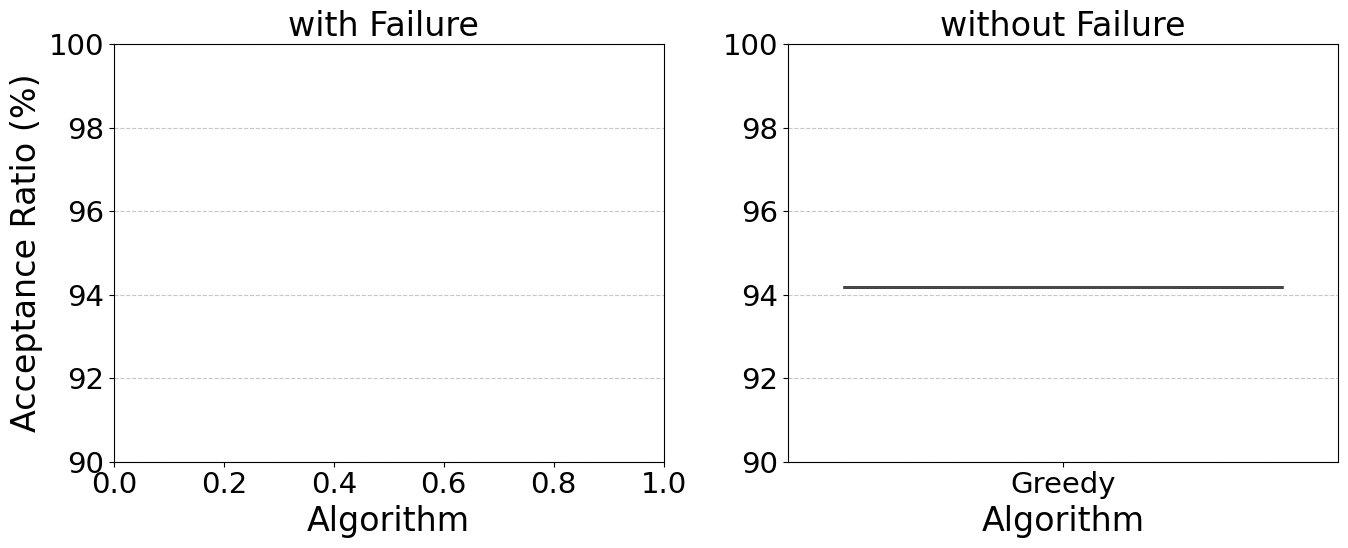

In [814]:
mplot_dual_boxplot(
    dataframe1=acceptance_com_falha,
    dataframe2=acceptance_sem_falha,
    x_col="algorithm",
    y_col="success",
    title1="with Failure ",
    title2="without Failure",
    y_range=(90, 100),
    y_title="Acceptance Ratio (%)",
    x_title="Algorithm",
)

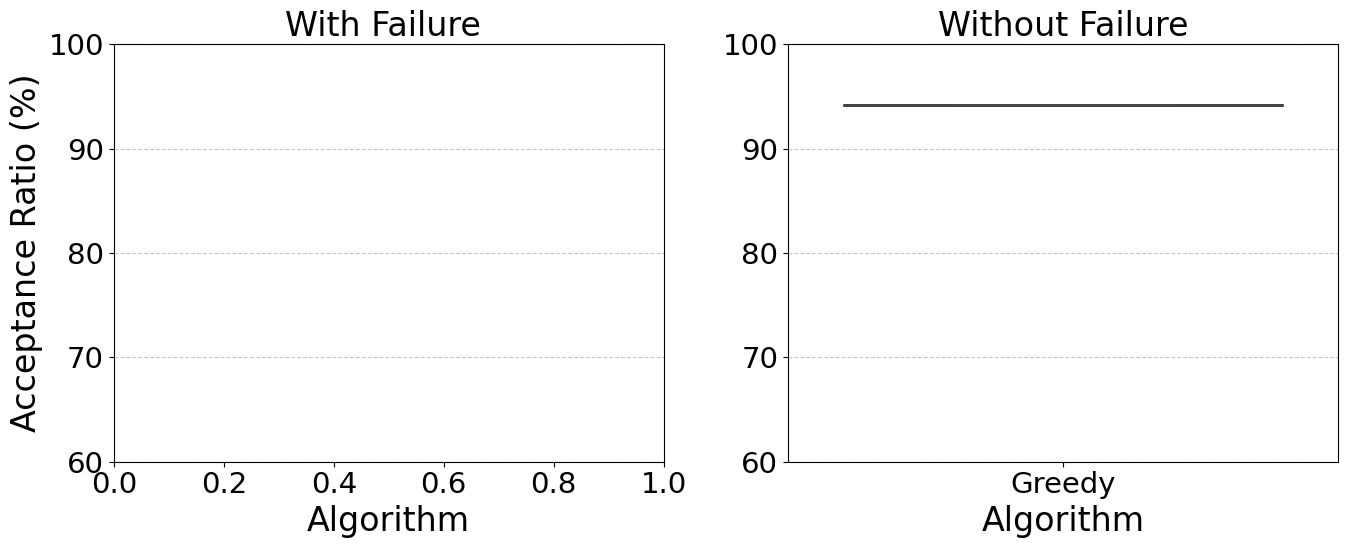

In [815]:
mplot_dual_boxplot(
    dataframe1=acceptance_com_falha,
    dataframe2=acceptance_sem_falha,
    x_col="algorithm",
    y_col="success",
    title1="With Failure ",
    title2="Without Failure",
    y_range=(60, 100),
    y_title="Acceptance Ratio (%)",
    x_title="Algorithm",
)

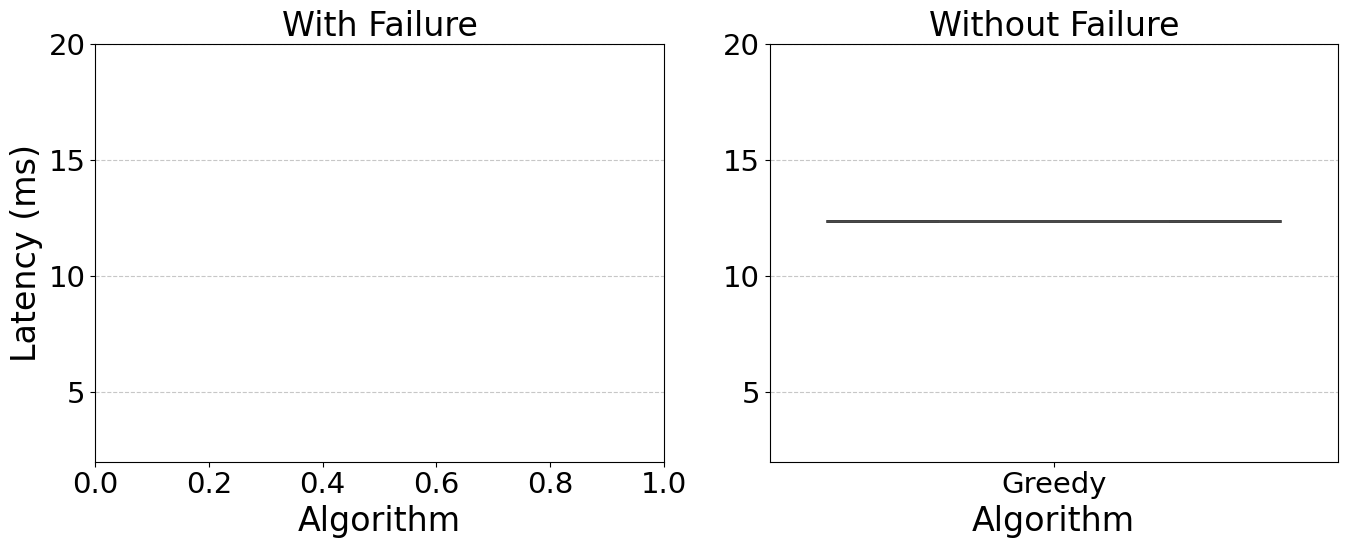

In [816]:
mplot_dual_boxplot(
    dataframe1=latency_com_falha,
    dataframe2=latency_sem_falha,
    x_col="algorithm",
    y_col="latency",
    title1="With Failure",
    title2="Without Failure",
    y_range=(2, 20),
    y_title="Latency (ms)",
    x_title="Algorithm",
)

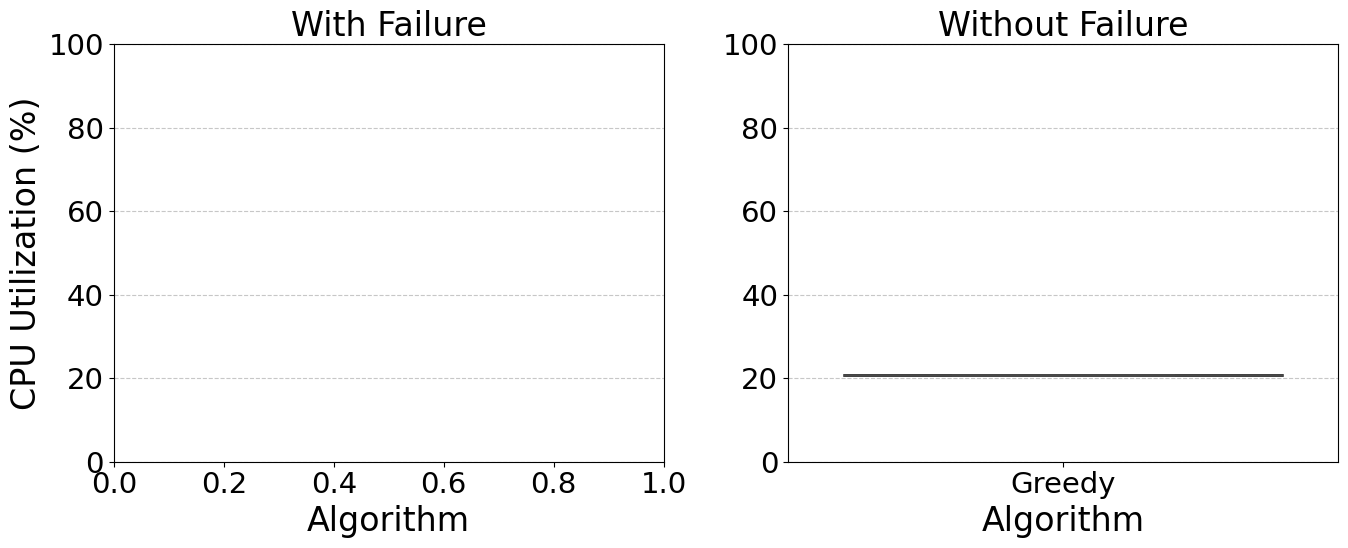

In [817]:
# Gerar o gráfico
mplot_dual_boxplot(
    dataframe1=dados_consumo_com_falha,
    dataframe2=dados_consumo_sem_falha,
    x_col="algorithm",
    y_col="cpu_utilization",
    title1="With Failure",
    title2="Without Failure",
    y_range=(0, 100),
    y_title="CPU Utilization (%)",
    x_title="Algorithm",
)

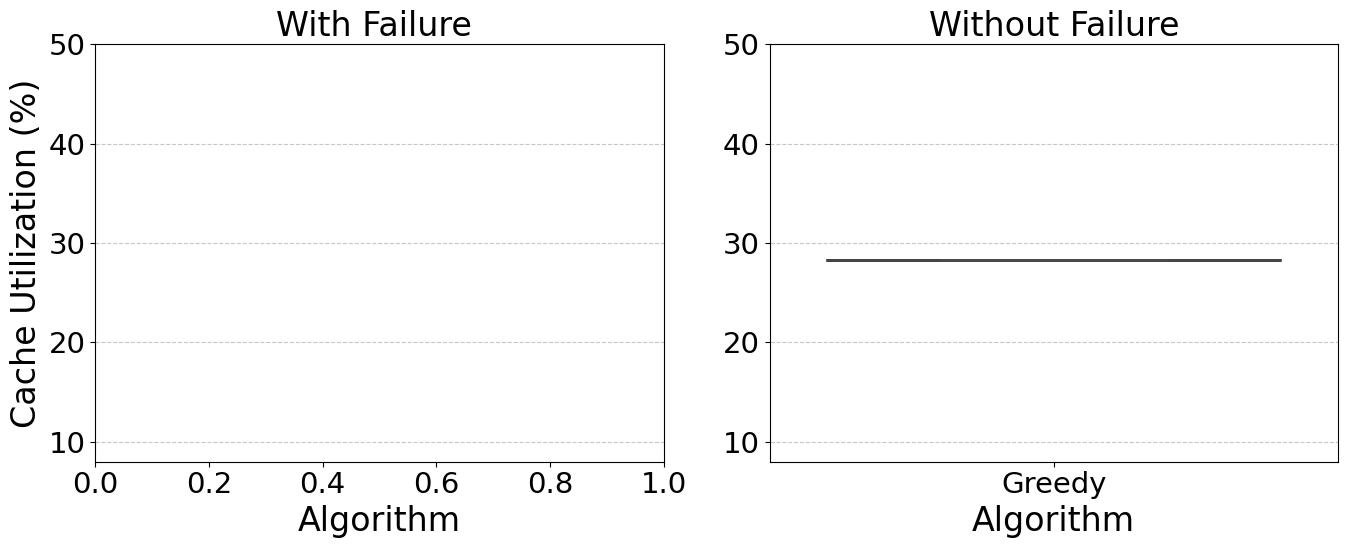

In [818]:
mplot_dual_boxplot(
    dataframe1=dados_consumo_com_falha,
    dataframe2=dados_consumo_sem_falha,
    x_col="algorithm",
    y_col="cache_utilization",
    title1="With Failure ",
    title2="Without Failure",
    y_range=(8, 50),
    y_title="Cache Utilization (%)",
    x_title="Algorithm",
)

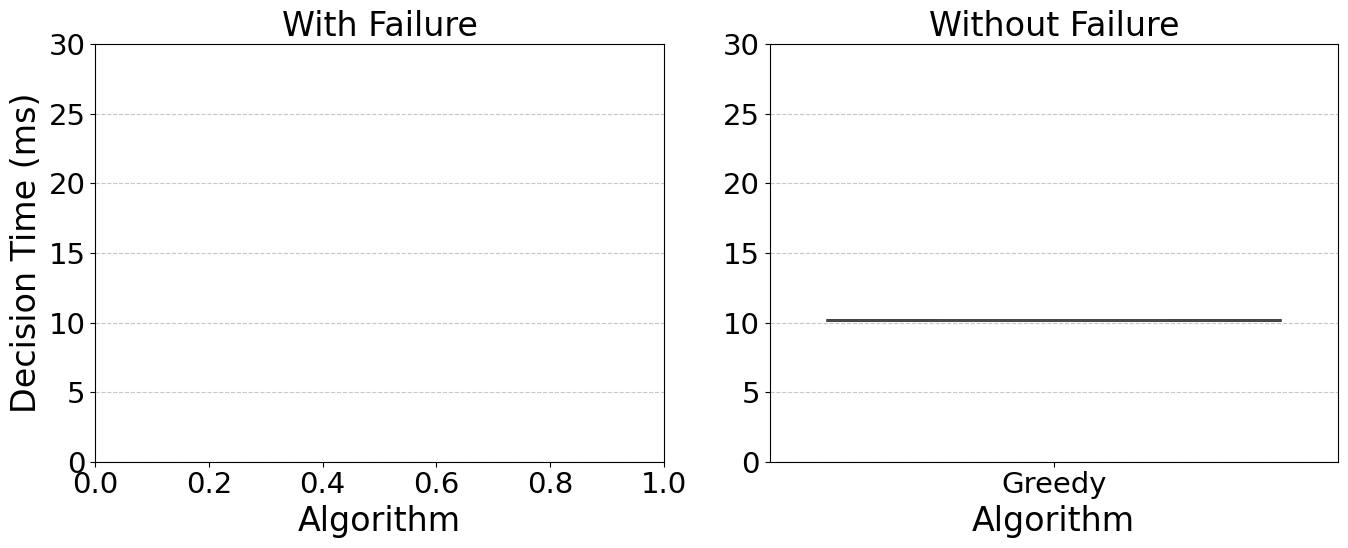

In [819]:
mplot_dual_boxplot(
    dataframe1=dados_consumo_com_falha,
    dataframe2=dados_consumo_sem_falha,
    x_col="algorithm",
    y_col="decision_time_ms",
    title1="With Failure",
    title2="Without Failure",
    y_range=(0, 30),
    y_title="Decision Time (ms)",
    x_title="Algorithm",
)

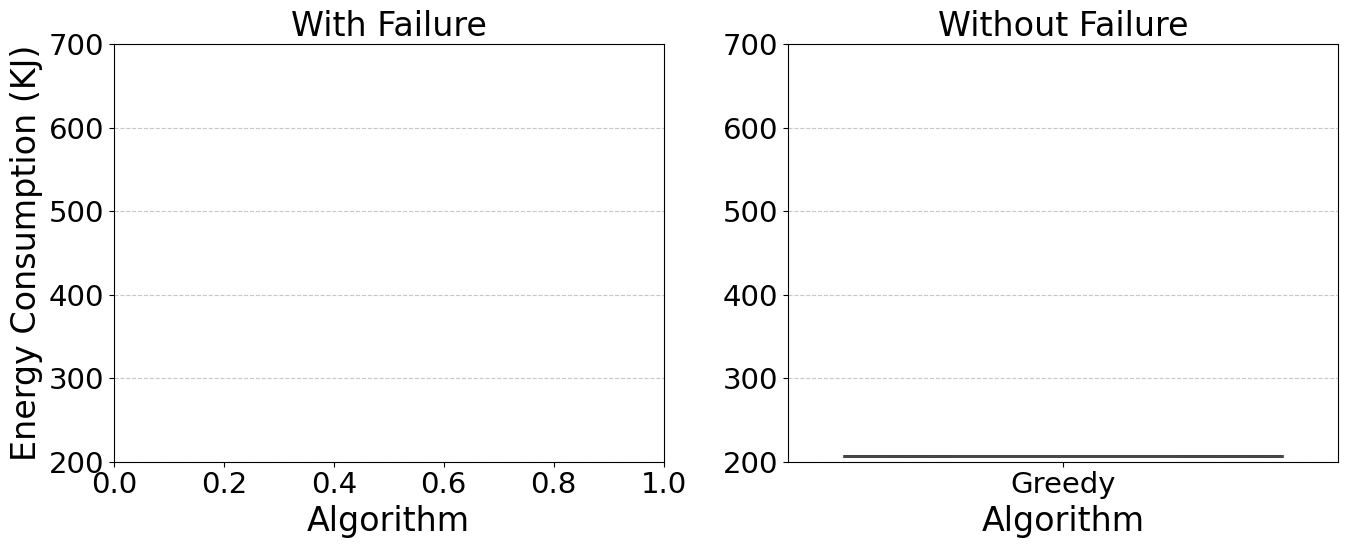

In [820]:
mplot_dual_boxplot(
    dataframe1=dados_consumo_com_falha,
    dataframe2=dados_consumo_sem_falha,
    x_col="algorithm",
    y_col="energy_consumption_KJ",
    title1="With Failure",
    title2="Without Failure",
    y_range=(200, 700),
    y_title="Energy Consumption (KJ)",
    x_title="Algorithm",
)

# ah, experimentar

In [821]:
import pandas as pd

hatches = ["/", "\\", "+", "x", "+", "x", "o", "O", ".", "*"]  # Padrões de hachura


def mplot_single_boxplot(
    dataframe1,
    dataframe2,
    x_col,
    y_col,
    title="Boxplot Comparativo",
    x_title=None,
    y_title=None,
    y_range=None,
    width=14,
    height=6,
    save=False,
):
    """
    Plota um único boxplot comparativo com robustez a dados ausentes:
    - Se um dos dataframes estiver vazio, plota apenas o outro.
    - Se só houver um dataframe, não usa hue.
    - A paleta é criada dinamicamente apenas para os níveis presentes.
    """

    # Normalizar entradas: permitir None e DataFrames vazios
    dfs = []
    if dataframe1 is not None and isinstance(dataframe1, pd.DataFrame) and not dataframe1.empty:
        df1 = dataframe1.copy()
        df1["Dataframe"] = "Dataframe1"
        dfs.append(df1)

    if dataframe2 is not None and isinstance(dataframe2, pd.DataFrame) and not dataframe2.empty:
        df2 = dataframe2.copy()
        df2["Dataframe"] = "Dataframe2"
        dfs.append(df2)

    if not dfs:
        raise ValueError(
            "Nenhum dado disponível para plotar (ambos os dataframes estão vazios ou None)."
        )

    combined_df = pd.concat(dfs, ignore_index=True)

    # Garantir que x_col e y_col existem
    for col in [x_col, y_col]:
        if col not in combined_df.columns:
            raise KeyError(
                f"Coluna '{col}' não encontrada nos dados combinados. Colunas: {list(combined_df.columns)}"
            )

    # Limitar às categorias PRESENTES no eixo X (evita espaços reservados para categorias ausentes)
    present_x_levels = combined_df[x_col].dropna().unique().tolist()
    # Se quiser uma ordenação específica, ajuste aqui (ex.: sorted)
    order = present_x_levels

    # Decidir se haverá hue
    hue = (
        "Dataframe"
        if "Dataframe" in combined_df.columns and combined_df["Dataframe"].nunique() > 1
        else None
    )

    # Construir paleta dinamicamente apenas com níveis presentes no hue
    palette = None
    if hue:
        present_hue_levels = combined_df[hue].dropna().unique().tolist()
        # Paleta simples e segura (duas cores padrão do matplotlib)
        base_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # expande se necessário
        # Mapear só níveis presentes
        palette = {
            lvl: base_colors[i % len(base_colors)] for i, lvl in enumerate(present_hue_levels)
        }

    # Criar figura e eixo
    fig, ax = plt.subplots(figsize=(width, height))

    # Isolar configuração de fonte só para este plot
    with plt.rc_context({"font.size": 24}):
        # Plotar boxplot
        sns.boxplot(
            data=combined_df,
            x=x_col,
            y=y_col,
            hue=hue,
            order=order,
            ax=ax,
            palette=palette,  # pode ser None (Seaborn escolhe)
            linewidth=2,
            showfliers=False,
            dodge=True
            if hue
            else False,  # não faz diferença, mas evita deslocamento quando não há hue
        )

        # Adicionar hachuras: pega os patches realmente criados
        patches = [p for p in ax.patches if isinstance(p, mpl.patches.PathPatch)]
        if patches:
            reps = (len(patches) // len(hatches)) + 1
            h_list = (hatches * reps)[: len(patches)]
            for patch, hatch in zip(patches, h_list):
                patch.set_hatch(hatch)
                patch.set_edgecolor("black")

        # Títulos e rótulos
        ax.set_title(title, fontsize=24)
        ax.set_xlabel(x_title if x_title else x_col, fontsize=24)
        ax.set_ylabel(y_title if y_title else y_col, fontsize=24)

        # Grade e limites
        ax.grid(True, axis="y", linestyle="--", alpha=0.7)
        if y_range:
            ax.set_ylim(y_range)

        # Ticks
        ax.tick_params(axis="y", labelsize=21)
        ax.tick_params(axis="x", labelsize=21)

        # Legend: só se houver hue
        if hue:
            ax.legend(title=hue, fontsize=18, title_fontsize=18, frameon=True)
        else:
            leg = ax.get_legend()
            if leg:
                leg.remove()

        plt.tight_layout()

        # Salvar se solicitado
        if save and y_col:
            plt.savefig(f"{y_col}_comp.pdf", format="pdf", bbox_inches="tight")

    plt.show()

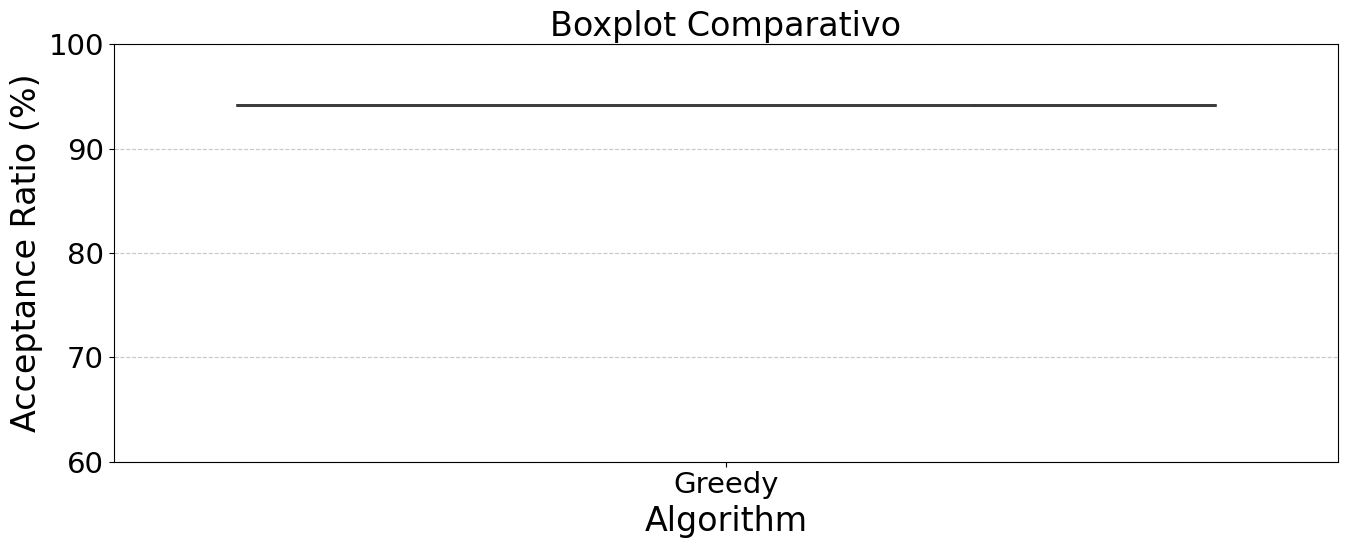

In [822]:
mplot_single_boxplot(
    dataframe1=acceptance_com_falha,
    dataframe2=acceptance_sem_falha,
    x_col="algorithm",
    y_col="success",
    y_range=(60, 100),
    y_title="Acceptance Ratio (%)",
    x_title="Algorithm",
)

In [823]:
aggregated_simulation_data = pd.DataFrame()
algos = {}


def collect_data_from_alg_directory(results_res_directories):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_res_directories:
        simu_exec_name = alg_dir.split("/")[-1].split("_")
        alg_name = simu_exec_name[1].split("\\")[1]
        simu_exec_name[-1]
        simu_exec_name[-3]
        # reliability = simu_exec_name[-1]
        if alg_name == "g":
            alg_name = "Greedy"
        if alg_name == "ga":
            alg_name = "GA"
        if alg_name == "msf":
            alg_name = "MSF"
        if alg_name == "goku":
            alg_name = "OSCIM"
        if alg_name == "vegeta":
            alg_name = "Resilient-OSCIM"
        if alg_name == "musfico":
            alg_name = "MuSFiCO"
        if alg_name == "old":
            alg_name = "All Backup"
        files = os.listdir(alg_dir)
        # print(f"Simulação: {alg_name}, {reliability}")
        # print("Quantidade de csv: ", len(files))

        if alg_name not in log_simu:
            log_simu[alg_name] = {"files": len(files), "simulacoes_sucesso": 0, "Nulos": 0}
        else:
            log_simu[alg_name]["files"] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue

            if not simulation_df.empty:
                # Calculations
                mean_data_frame = pd.DataFrame()
                recover_success_rate = simulation_df["recover_success"].mean()
                backup_success_rate = simulation_df["backup_success"].mean()
                latency_diff_mean = simulation_df["latency_diff"].dropna().mean()
                time_to_recover_mean = simulation_df["time_to_recover"].dropna().mean()

                # Cálculo do percentual de melhoria da latência
                improvement_percentage = ((5 - latency_diff_mean) / 10) * 100

                mean_data_frame["recover_success"] = [recover_success_rate]
                mean_data_frame["backup_success"] = [backup_success_rate]
                mean_data_frame["latency_diff"] = [latency_diff_mean]
                mean_data_frame["latency_improvement"] = [improvement_percentage]
                mean_data_frame["time_to_recover"] = [time_to_recover_mean]

                # Seleciona as métricas relevantes
                mean_data_frame["algorithm"] = alg_name
                mean_data_frame["simulation"] = log_simu[alg_name]["simulacoes_sucesso"]
                print(mean_data_frame)
                # print(mean_data_frame)
                data_nla.append(mean_data_frame)

                # Incrementa a contagem de simulações de sucesso e soma os valores nulos
                log_simu[alg_name]["simulacoes_sucesso"] += 1
                log_simu[alg_name]["Nulos"] += sum(mean_data_frame.isnull().sum())
    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [824]:
import pandas as pd

# ----- Dados -----
# Se você já tem aggregated_simulation_data, descomente a linha abaixo:
# df = aggregated_simulation_data.copy()

metric = "recover_success"

df = concatenate_data

# Verificações básicas
if "df" not in globals():
    raise NameError(
        "A variável 'df' não está definida. Atribua df = aggregated_simulation_data.copy() (ou similar)."
    )

required_cols = {"algorithm", metric}
missing = required_cols - set(df.columns)
if missing:
    raise KeyError(f"As seguintes colunas não foram encontradas em df: {missing}")

# Remover linhas sem os dados necessários
plot_df = df[["algorithm", metric]].dropna(subset=["algorithm", metric]).copy()
if plot_df.empty:
    raise ValueError(
        "Não há dados válidos após remover valores ausentes em 'algorithm' e na métrica."
    )

# Ordem das categorias presentes em 'algorithm'
order = list(pd.unique(plot_df["algorithm"]))

# ----- Plot -----
sns.set(style="whitegrid", font_scale=1.2)

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(x="algorithm", y=metric, data=plot_df, order=order, linewidth=1.5, fliersize=3, ax=ax)

# Desenhar a média de cada algoritmo (overlay)
means = plot_df.groupby("algorithm")[metric].mean()
# Posições categóricas são 0..len(order)-1
xpos = range(len(order))
ax.scatter(
    xpos,
    [means.get(cat, float("nan")) for cat in order],
    s=80,
    facecolor="red",
    edgecolor="black",
    zorder=3,
    label="Mean",
)

# Personalização
ax.set_title(f"Boxplot for {metric}", fontsize=18)
ax.set_xlabel("Algorithm", fontsize=14)
ax.set_ylabel(metric.replace("_", " ").title(), fontsize=14)

# Legenda para a média
handles, labels = ax.get_legend_handles_labels()
if "Mean" not in labels:
    from matplotlib.lines import Line2D

    mean_legend = Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="red",
        markeredgecolor="black",
        markersize=8,
        label="Mean",
    )
    handles.append(mean_legend)
    labels.append("Mean")
ax.legend(handles, labels, frameon=True)

plt.tight_layout()
plt.show()

KeyError: "As seguintes colunas não foram encontradas em df: {'recover_success'}"

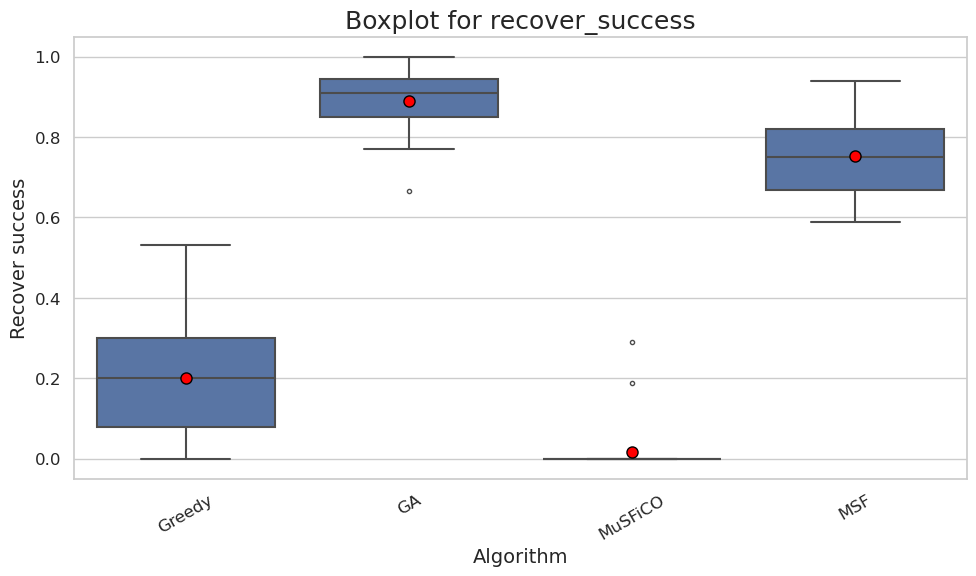

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suposta estrutura do dataframe
# df = aggregated_simulation_data

# Apenas a métrica "recover_success"
metric = "recover_success"

# Configuração do estilo e tamanho da figura
sns.set(style="whitegrid", font_scale=1.2)

# Criação do gráfico de caixa para a métrica selecionada
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="algorithm",
    y=metric,
    data=df,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": 8,
    },
    linewidth=1.5,
    fliersize=3,
)

# Personalização do gráfico
plt.title(f"Boxplot for {metric}", fontsize=18)
plt.xlabel("Algorithm", fontsize=14)
plt.ylabel(metric.replace("_", " ").capitalize(), fontsize=14)
plt.xticks(rotation=30, fontsize=12)
plt.yticks(fontsize=12)

# Ajusta o layout para melhor visualização
plt.tight_layout()

# Exibir o gráfico
plt.show()